# Ejercicio 1 - Concepto de Modelo

## MD009 Eines avançades d'anàlisi de dades
### Gerard Pascual Fontanilles

**Estamos realizando un estudio sobre los hábitos e intereses de los adolescentes. Para ello, hemos realizado una encuesta a un grupo de 100 personas entre 15 y 17 años. Una información que podemos analizar es el número de libros que han leído en el último año. El número de libros leído por persona es el siguiente:**

In [4]:
nx <- c(
  4, 3, 2, 2, 4, 1, 3, 5, 1, 4, 2, 2, 2, 3, 4, 1, 4, 0, 3, 3,
  1, 0, 0, 1, 2, 5, 0, 1, 4, 1, 4, 5, 3, 4, 2, 6, 2, 1, 1, 1,
  2, 4, 2, 5, 6, 0, 3, 0, 3, 5, 1, 0, 3, 2, 5, 1, 3, 1, 4, 2,
  1, 2, 2, 2, 3, 1, 1, 4, 5, 0, 2, 1, 3, 7, 8, 4, 1, 2, 4, 0,
  3, 3, 2, 7, 1, 2, 3, 3, 3, 1, 3, 4, 1, 3, 3, 0, 3, 1, 2, 0
)

**1) Representa el histograma de frecuencias del número de libros leídos por persona y calcula el valor medio.**

Para comenzar el análisis, calcularemos la media aritmética de nuestra muestra. A continuación, representaremos la distribución empírica de los datos mediante un histograma.

Dado que la variable analizada ("número de libros leídos") es estrictamente discreta (toma valores enteros no negativos), ajustaremos los límites de las barras del histograma para que queden perfectamente centradas en cada número entero. Además, añadiremos una marca visual (línea roja punteada) que nos indicará la posición exacta del valor medio dentro de la distribución de la muestra.

In [5]:
media_libros <- mean(nx)

print(paste("El valor medio de libros leídos es:", media_libros))

[1] "El valor medio de libros leídos es: 2.5"


El valor medio calculado es exactamente de 2.5 libros leídos al año por persona.

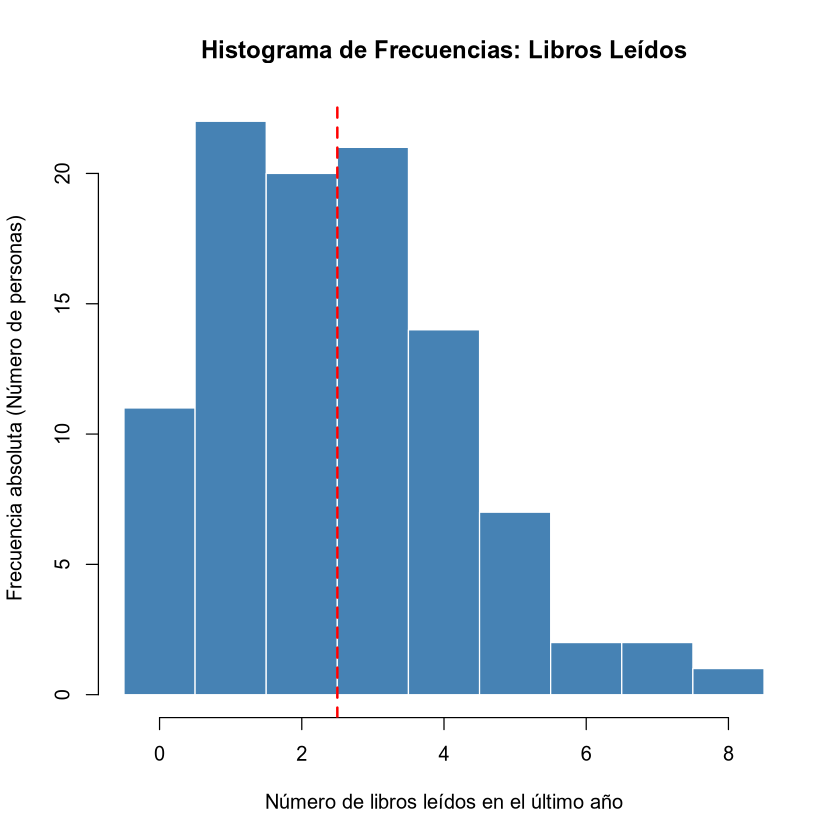

In [6]:
hist(nx,
  breaks = seq(-0.5, max(nx) + 0.5, by = 1),
  main = "Histograma de Frecuencias: Libros Leídos",
  xlab = "Número de libros leídos en el último año",
  ylab = "Frecuencia absoluta (Número de personas)",
  col = "steelblue",
  border = "white"
)

abline(v = media_libros, col = "red", lwd = 2, lty = 2)

Al observar el histograma, notamos una clara distribución asimétrica hacia la derecha (sesgo positivo). La gran mayoría de los adolescentes encuestados lee entre 1 y 4 libros, mientras que los valores más altos (6, 7 u 8 libros) conforman una larga cola de casos mucho menos frecuentes.

Esta forma fuertemente asimétrica y el hecho de estar tratando con datos de conteo (enteros positivos) nos da una primera pista visual de que no estamos ante una distribución Normal.

**2) ¿Con qué famosa distribución de probabilidad podríamos modelizar el histograma anterior? Prueba a realizar un ajuste de la distribución de probabilidad escogida sobre los datos.**

Al analizar nuestra variable ("número de libros leídos en un año"), constatamos que representa el recuento de un evento en un intervalo de tiempo fijo. Por tanto, estamos ante una variable discreta. La distribución teórica ideal para modelizar este tipo de sucesos es la distribución de Poisson.

Esta distribución de probabilidad discreta depende de un único parámetro, $\lambda$, que representa el valor esperado o media. Para realizar el ajuste formal en R, utilizaremos la función fitdistr() de la librería MASS, que calculará el estimador óptimo para $\lambda$. Tras obtenerlo, generaremos la curva de frecuencias esperadas y la superpondremos al histograma empírico para realizar una validación visual del modelo.

[1] "El parámetro lambda estimado para nuestro modelo Poisson es: 2.5"


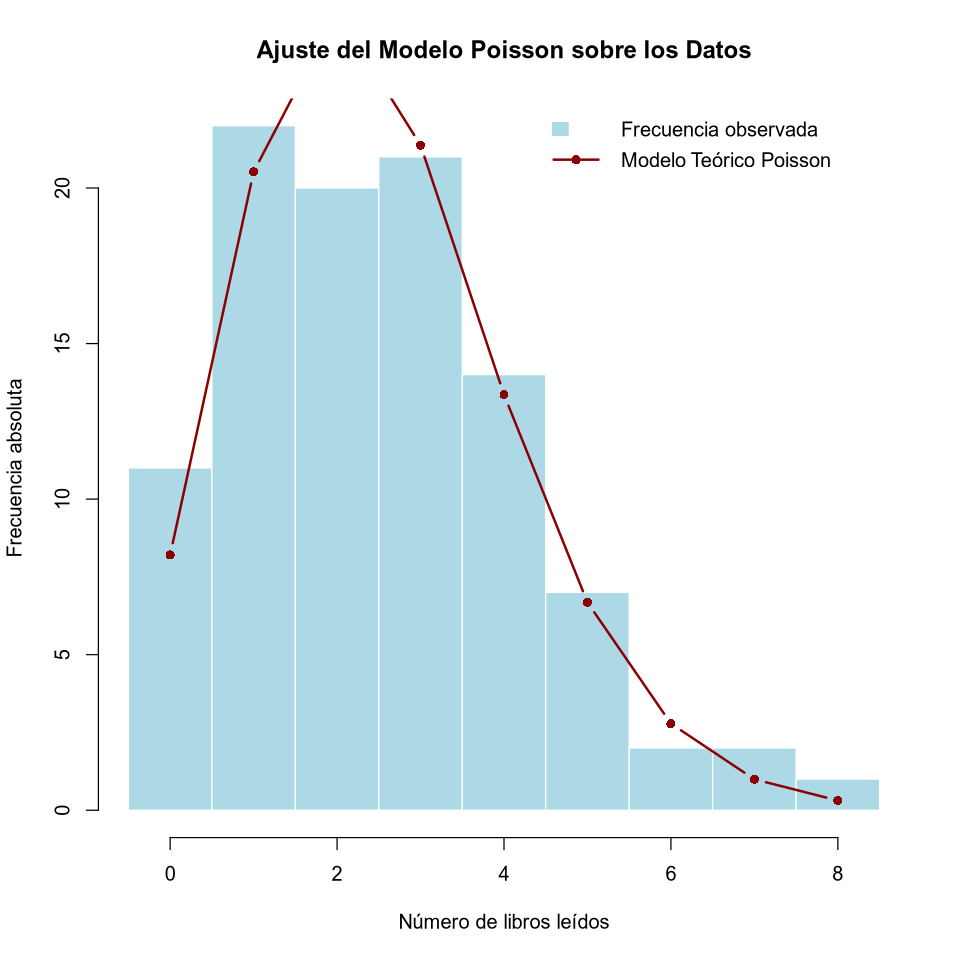

In [17]:
options(repr.plot.width = 8, repr.plot.height = 8)

library(MASS)

ajuste_poisson <- fitdistr(nx, densfun = "Poisson")

lambda_est <- ajuste_poisson$estimate[["lambda"]]
print(paste(
  "El parámetro lambda estimado para nuestro modelo Poisson es:",
  round(lambda_est, 3)
))

hist(nx,
  breaks = seq(-0.5, max(nx) + 0.5, by = 1),
  main = "Ajuste del Modelo Poisson sobre los Datos",
  xlab = "Número de libros leídos",
  ylab = "Frecuencia absoluta",
  col = "lightblue",
  border = "white"
)

valores_x <- 0:max(nx)

probabilidades_teoricas <- dpois(valores_x, lambda = lambda_est)

frecuencias_esperadas <- probabilidades_teoricas * length(nx)

lines(valores_x, frecuencias_esperadas,
  type = "b", pch = 16,
  col = "darkred", lwd = 2
)

legend("topright",
  legend = c("Frecuencia observada", "Modelo Teórico Poisson"),
  fill = c("lightblue", NA), border = c("white", NA),
  col = c(NA, "darkred"), pch = c(NA, 16), lty = c(NA, 1),
  lwd = c(NA, 2), bty = "n"
)

El ajuste matemático estima un parámetro $\lambda = 2.5$. Esto tiene todo el sentido estadístico, ya que la media teórica de una distribución de Poisson equivale a $\lambda$, coincidiendo exactamente con el valor medio que calculamos empíricamente.

Al observar la gráfica, la curva del modelo teórico de Poisson (granate) captura muy bien la tendencia general de los datos empíricos (celeste), especialmente el rápido decaimiento hacia la cola derecha a partir de los 4 libros.

No obstante, al analizar la zona de mayor concentración, observamos el efecto de la variabilidad muestral: mientras que el modelo teórico impone su pico máximo estricto en los 2 libros (frecuencia esperada de $\approx 25.6$), los datos observados forman una pequeña "U" en ese tramo, presentando un ligero valle en los 2 libros (20 personas) flanqueado por recuentos mayores en 1 y 3 libros (22 y 21 personas respectivamente).

Pese a esta particularidad local (ruido estadístico normal en una muestra de 100 personas), la inspección visual sugiere que el modelo general es muy idóneo para reproducir el fenómeno.

 **3) Representa gráficamente la función densidad de probabilidad y acumulada de la distribución teórica (del ajuste) superpuesta a la de los datos. ¿Parece un buen ajuste?**

Para evaluar la idoneidad del modelo seleccionado, no basta con observar las frecuencias absolutas. Es necesario comparar las distribuciones de probabilidad reales de nuestra muestra con las dictadas por el modelo matemático ideal.

Puesto que estamos trabajando con una variable discreta, calcularemos la Función de Masa de Probabilidad (PMF) (el equivalente discreto a la función de densidad) y la Función de Distribución Acumulada (CDF).
* En el primer gráfico, damos un paso más respecto a la visualización anterior: pasamos de representar frecuencias absolutas a frecuencias relativas (probabilidades de 0 a 1). De esta forma, construimos la Función de Masa de Probabilidad (PMF) empírica de nuestros datos y la confrontamos directamente con las probabilidades teóricas arrojadas por la distribución de Poisson (λ = 2.5).
* En el segundo gráfico, compararemos la CDF empírica (la probabilidad observada de que se lean $x$ libros o menos) con la CDF teórica. Esta comparación acumulada nos permitirá ver de forma clara si las dos distribuciones divergen significativamente en algún tramo.

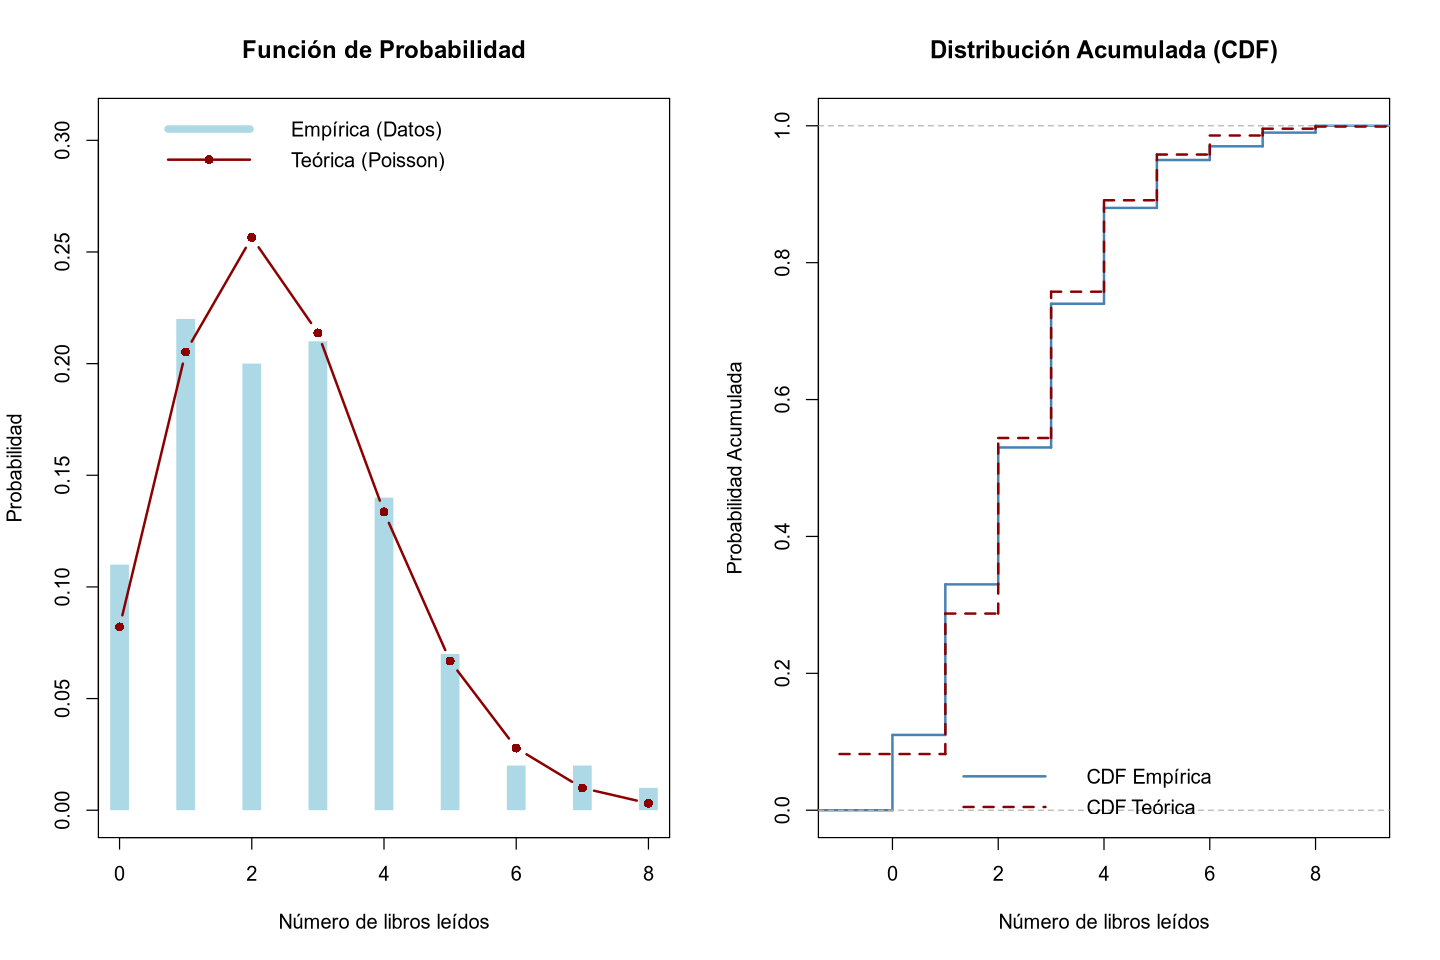

In [14]:
options(repr.plot.width = 12, repr.plot.height = 8)

lambda_est <- 2.5

par(mfrow = c(1, 2))

x_vals <- 0:max(nx)

emp_probs <- as.numeric(prop.table(table(factor(nx, levels = x_vals))))

teo_probs <- dpois(x_vals, lambda = lambda_est)

plot(x_vals, emp_probs,
  type = "h", lwd = 15, col = "lightblue", lend = 1,
  main = "Función de Probabilidad",
  xlab = "Número de libros leídos", ylab = "Probabilidad",
  ylim = c(0, max(c(emp_probs, teo_probs)) + 0.05)
)

lines(x_vals, teo_probs, type = "b", pch = 16, col = "darkred", lwd = 2)

legend("topright",
  legend = c("Empírica (Datos)", "Teórica (Poisson)"),
  col = c("lightblue", "darkred"), lwd = c(6, 2), pch = c(NA, 16), bty = "n"
)

cdf_emp <- ecdf(nx)

plot(cdf_emp,
  main = "Distribución Acumulada (CDF)",
  xlab = "Número de libros leídos", ylab = "Probabilidad Acumulada",
  col = "steelblue", lwd = 2, verticals = TRUE, do.points = FALSE
)

teo_cdf <- ppois(x_vals, lambda = lambda_est)

lines(stepfun(x_vals[-1], teo_cdf),
  col = "darkred",
  lwd = 2, lty = 2, do.points = FALSE
)

legend("bottomright",
  legend = c("CDF Empírica", "CDF Teórica"),
  col = c("steelblue", "darkred"), lwd = 2, lty = c(1, 2), bty = "n"
)

par(mfrow = c(1, 1))

A la luz de las representaciones gráficas generadas, confirmamos que el ajuste de Poisson ($\lambda = 2.5$) es analíticamente sólido. Además, la comparación conjunta de ambas gráficas nos permite entender a la perfección cómo las fluctuaciones propias de una muestra real de 100 personas afectan al modelo ideal:

1. Función de Masa de Probabilidad (PMF): En el gráfico de la izquierda observamos una gran concordancia geométrica general. Sin embargo, una inspección minuciosa revela una pequeña divergencia producida por el ruido muestral en el centro de la distribución. El modelo teórico de Poisson impone que su moda (probabilidad máxima) esté en $x=2$, alcanzando un valor aproximado de $0.26$. En contraste, la distribución empírica muestra una leve caída o forma de "U" en ese punto exacto ($P = 0.20$), tal y como ya habíamos observado en el histograma del apartado anterior. Al estar rodeada de probabilidades empíricas superiores en $x=1$ ($0.22$) y $x=3$ ($0.21$), esta asimetría nos muestra la diferencia clásica entre la teoría perfecta y la realidad empírica.
2. Distribución Acumulada (CDF): Puesto que la función acumulada no es más que la suma secuencial de las probabilidades de la PMF, todo lo observado anteriormente tiene un reflejo directo en el gráfico de la derecha, convirtiéndolo en la prueba visual más rigurosa para evaluar el ajuste global:
    * El inicio ($x=0$ y $x=1$): Como en la muestra empírica hubo más personas que leyeron 0 o 1 libro de las que predecía la teoría, la línea azul empírica arranca acumulando más rápido y se sitúa por encima de la teórica (aprox. $0.35$ frente a $0.29$ en $x=1$).
    * El punto de compensación ($x=2$): Es aquí donde ocurre el cruce clave. Al llegar al escalón de los 2 libros, la curva empírica suma el valor bajo de su "valle" ($0.20$), mientras que el modelo teórico suma de golpe su gran pico ($0.26$). Este gran salto teórico compensa el retraso inicial, haciendo que la línea granate punteada alcance a la empírica.
    * Convergencia final: A partir de ese punto de compensación, ambas curvas estabilizan su crecimiento y avanzan de forma prácticamente paralela hasta converger en el $1.0$.

> La coherencia entre ambos gráficos demuestra que las pequeñas discrepancias locales no son más que ruido estadístico natural. Al no apreciarse desviaciones sistemáticas severas ni cambios de pendiente contradictorios en la CDF, queda en evidencia que la tasa de acumulación de nuestros datos empíricos es altamente compatible con el proceso de Poisson propuesto.

**4) Comprueba con el método del $\chi^2$ que el modelo escogido describe correctamente los datos.**

Para confirmar analíticamente lo que hemos observado en los gráficos, aplicaremos el Test de Pearson o $\chi^{2}$. Este es un test de bondad de ajuste válido para distribuciones discretas y continuas.

El método compara las frecuencias empíricas de la muestra con las frecuencias esperadas a partir de la distribución teórica, evaluando el siguiente estadístico:

$$\chi^{2}=\sum_{i=1}^{r}\frac{(O_{i}-E_{i})^{2}}{E_{i}}$$

Donde $r$ es el número de intervalos, $O_{i}$ es la frecuencia observada en el intervalo $i$, y $E_{i}$ es la frecuencia esperada según el modelo de Poisson.

Para que el cálculo matemático sea robusto y no arroje errores por falta de datos, agruparemos la cola derecha de la distribución (valores de 5, 6, 7 y 8 libros) en un único intervalo ("$\ge 5$"), asegurando así frecuencias esperadas estables.

Finalmente, el ajuste del modelo se rechaza si el estadístico calculado supera el umbral crítico: $\chi^{2}\ge\chi_{\alpha,r-p-1}^{2}$. El término $(r-p-1)$ indica el número de grados de libertad, donde $\alpha$ será nuestro nivel de significancia (0.05) y $p$ es el número de parámetros del modelo que hemos estimado.

In [12]:
obs <- table(nx)

obs_agrupadas <- c(obs[1:5], sum(obs[6:9]))
names(obs_agrupadas) <- c("0", "1", "2", "3", "4", ">=5")

lambda <- 2.5
N <- 100

probs_teo <- dpois(0:4, lambda)

prob_mayor_igual_5 <- 1 - ppois(4, lambda)

probs_agrupadas <- c(probs_teo, prob_mayor_igual_5)
esp_agrupadas <- probs_agrupadas * N

chi_cuadrado <- sum((obs_agrupadas - esp_agrupadas)^2 / esp_agrupadas)
print(paste("Estadístico Chi-cuadrado calculado:", round(chi_cuadrado, 3)))

df <- length(obs_agrupadas) - 1 - 1
print(paste("Grados de libertad (df):", df))

alfa <- 0.05

valor_critico <- qchisq(1 - alfa, df)
p_valor <- 1 - pchisq(chi_cuadrado, df)

print(paste("Valor crítico:", round(valor_critico, 3)))
print(paste("P-valor:", round(p_valor, 4)))

if (chi_cuadrado >= valor_critico) {
  print("CONCLUSIÓN: Se rechaza la hipótesis nula. El modelo no ajusta bien a los datos.")
} else {
  print("CONCLUSIÓN: No se rechaza la hipótesis nula. El modelo de Poisson ajusta bien a los datos.")
}

[1] "Estadístico Chi-cuadrado calculado: 2.453"
[1] "Grados de libertad (df): 4"
[1] "Valor crítico: 9.488"
[1] "P-valor: 0.6531"
[1] "CONCLUSIÓN: No se rechaza la hipótesis nula. El modelo de Poisson ajusta bien a los datos."


Tras agrupar los datos, nos quedan $r = 6$ intervalos (0, 1, 2, 3, 4 y $\ge 5$). Como hemos estimado $p = 1$ parámetro del modelo (el parámetro $\lambda$), los grados de libertad de nuestro test son $6 - 1 - 1 = 4$.

Hemos obtenido un estadístico $\chi^{2} = 2.453$. Al compararlo con la distribución Chi-cuadrado teórica para $\alpha = 0.05$ y 4 grados de libertad, el valor crítico límite es $9.488$.
* Puesto que $2.453 < 9.488$, no superamos el umbral crítico de rechazo. Además, el p-valor resultante es $0.6531$, holgadamente superior al umbral estándar de $0.05$.

CONCLUSIÓN: No existe evidencia estadística suficiente para rechazar la hipótesis nula. Queda demostrado cuantitativa y analíticamente que el modelo de Poisson (con $\lambda = 2.5$) es un ajuste excelente y describe correctamente la distribución de los datos sobre el número de libros leídos por los adolescentes.